# Практическая работа №1. Разведочный анализ данных

**ФИО:** Бухарин М. А.

**Группа:** 2384

**Ссылка на репозиторий:** https://github.com/bulterier94/vd_lab_2/tree/main/lab1


Набор данных относится к задаче классификации состояния системы водоснабжения.  
Цель работы: визуально оценить распределения признаков, наличие выбросов, переходный период системы и признаки, наиболее полезные для классификации.

## 1. Загрузка данных и первичный осмотр

Ниже данные загружаются автоматически: ноутбук ищет CSV-файл с названием, содержащим `Attack_DataSet`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["grid.alpha"] = 0.35

def find_csv():
    candidates = [
        Path("/mnt/data/0_1_Attack_DataSet.csv"),
        Path("0_1_Attack_DataSet.csv"),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError("Файл 0_1_Attack_DataSet.csv не найден.")

csv_path = find_csv()
df = pd.read_csv(csv_path)

print(f"Файл данных: {csv_path}")
print(f"Размерность: {df.shape[0]} строк × {df.shape[1]} столбцов")
df.head()

Файл данных: 0_1_Attack_DataSet.csv
Размерность: 7200 строк × 16 столбцов


,id_record_inc,watLevel_R1_3_bool,watLevel_R1_2_bool,watLevel_R1_1_bool,Fullness_R1_persent,Crane_state_persent,Flow_state_persent,watLevel_R2_3_bool,watLevel_R2_2_bool,watLevel_R2_1_bool,Fullness_R2_persent,Pump_state_bool,PumpFlow_state_persent,Time_sec,isAttack,classAttack
0,1,1,1,1,99.340,1.0,0.934,0,0,0,0.660,0,0.0,0.5,0,0
1,2,1,1,1,98.353,0.5,0.488,0,0,0,1.647,0,0.0,1.0,0,0
2,3,1,1,1,97.944,0.5,0.492,0,0,0,2.056,0,0.0,1.5,0,0
3,4,1,1,1,97.486,0.5,0.415,0,0,0,2.514,0,0.0,2.0,0,0
4,5,1,1,1,97.063,0.1,0.172,0,0,0,2.937,0,0.0,2.5,0,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_record_inc           7200 non-null   int64  
 1   watLevel_R1_3_bool      7200 non-null   int64  
 2   watLevel_R1_2_bool      7200 non-null   int64  
 3   watLevel_R1_1_bool      7200 non-null   int64  
 4   Fullness_R1_persent     7200 non-null   float64
 5   Crane_state_persent     7200 non-null   float64
 6   Flow_state_persent      7200 non-null   float64
 7   watLevel_R2_3_bool      7200 non-null   int64  
 8   watLevel_R2_2_bool      7200 non-null   int64  
 9   watLevel_R2_1_bool      7200 non-null   int64  
 10  Fullness_R2_persent     7200 non-null   float64
 11  Pump_state_bool         7200 non-null   int64  
 12  PumpFlow_state_persent  7200 non-null   float64
 13  Time_sec                7200 non-null   float64
 14  isAttack                7200 non-null   int64  
 15

In [3]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
id_record_inc,7200.0,3600.500000,2078.605302,1.000,1800.750,3600.5000,5400.250,7200.000
watLevel_R1_3_bool,7200.0,0.176806,0.381531,0.000,0.000,0.0000,0.000,1.000
watLevel_R1_2_bool,7200.0,0.162083,0.368553,0.000,0.000,0.0000,0.000,1.000
watLevel_R1_1_bool,7200.0,0.172917,0.378201,0.000,0.000,0.0000,0.000,1.000
Fullness_R1_persent,7200.0,10.679284,8.459536,4.315,6.835,9.4635,12.380,99.340
Crane_state_persent,7200.0,0.112861,0.251422,0.000,0.000,0.0000,0.000,1.000
Flow_state_persent,7200.0,0.112653,0.250261,0.000,0.000,0.0000,0.000,0.999
watLevel_R2_3_bool,7200.0,0.803611,0.397294,0.000,1.000,1.0000,1.000,1.000
watLevel_R2_2_bool,7200.0,0.832500,0.373448,0.000,1.000,1.0000,1.000,1.000
watLevel_R2_1_bool,7200.0,0.832222,0.373695,0.000,1.000,1.0000,1.000,1.000


In [4]:
print("Пропуски по столбцам:")
display(df.isnull().sum().to_frame("missing_count"))

print("Проверка, совпадают ли `isAttack` и `classAttack`:")
print((df["isAttack"] == df["classAttack"]).all())

Пропуски по столбцам:


,missing_count
id_record_inc,0
watLevel_R1_3_bool,0
watLevel_R1_2_bool,0
watLevel_R1_1_bool,0
Fullness_R1_persent,0
Crane_state_persent,0
Flow_state_persent,0
watLevel_R2_3_bool,0
watLevel_R2_2_bool,0
watLevel_R2_1_bool,0


Проверка, совпадают ли `isAttack` и `classAttack`:
True


## 2. Типы признаков

В наборе данных есть:

- служебные признаки: `id_record_inc`, `Time_sec`;
- бинарные / номинальные признаки состояния: `watLevel_*_bool`, `Pump_state_bool`;
- вещественные признаки состояния: `Fullness_*_persent`, `Crane_state_persent`, `Flow_state_persent`, `PumpFlow_state_persent`;
- целевой атрибут: `classAttack`.

Для классификации будем ориентироваться на `classAttack`. Признак `isAttack` полностью совпадает с ним, поэтому его удобно рассматривать как дубликат целевой переменной и не использовать в модели.

## 3. Одномерный анализ: распределения и выбросы

Сначала посмотрим на распределение числовых признаков.  
Для признаков состояния с резкими переходами boxplot может показывать много «выбросов», но в этой задаче это чаще не ошибка данных, а смена режима работы системы.

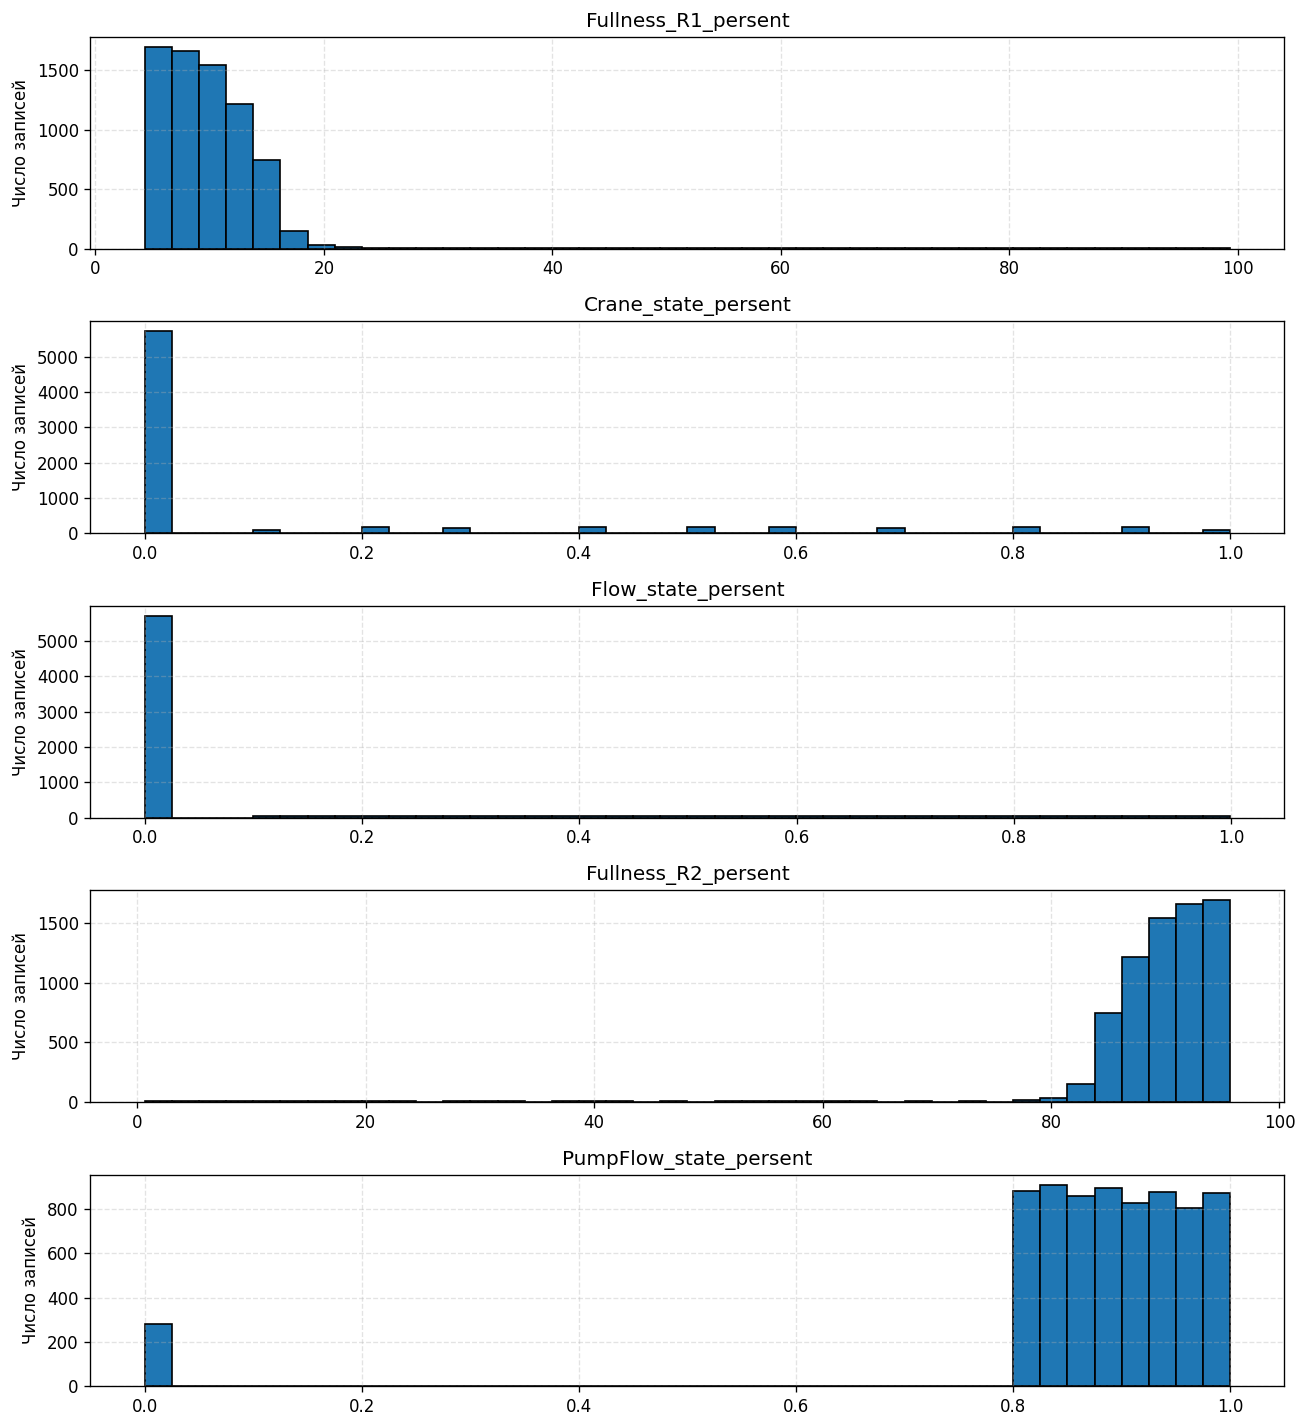

In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
service_cols = ["id_record_inc", "Time_sec", "isAttack", "classAttack"]
feature_cols = [c for c in numeric_cols if c not in service_cols]

continuous_cols = [
    "Fullness_R1_persent",
    "Crane_state_persent",
    "Flow_state_persent",
    "Fullness_R2_persent",
    "PumpFlow_state_persent",
]
binary_cols = [c for c in feature_cols if c not in continuous_cols]

fig, axes = plt.subplots(len(continuous_cols), 1, figsize=(11, 12), sharex=False)
for ax, col in zip(axes, continuous_cols):
    ax.hist(df[col], bins=40, edgecolor="black")
    ax.set_title(col)
    ax.set_ylabel("Число записей")
plt.tight_layout()
plt.show()

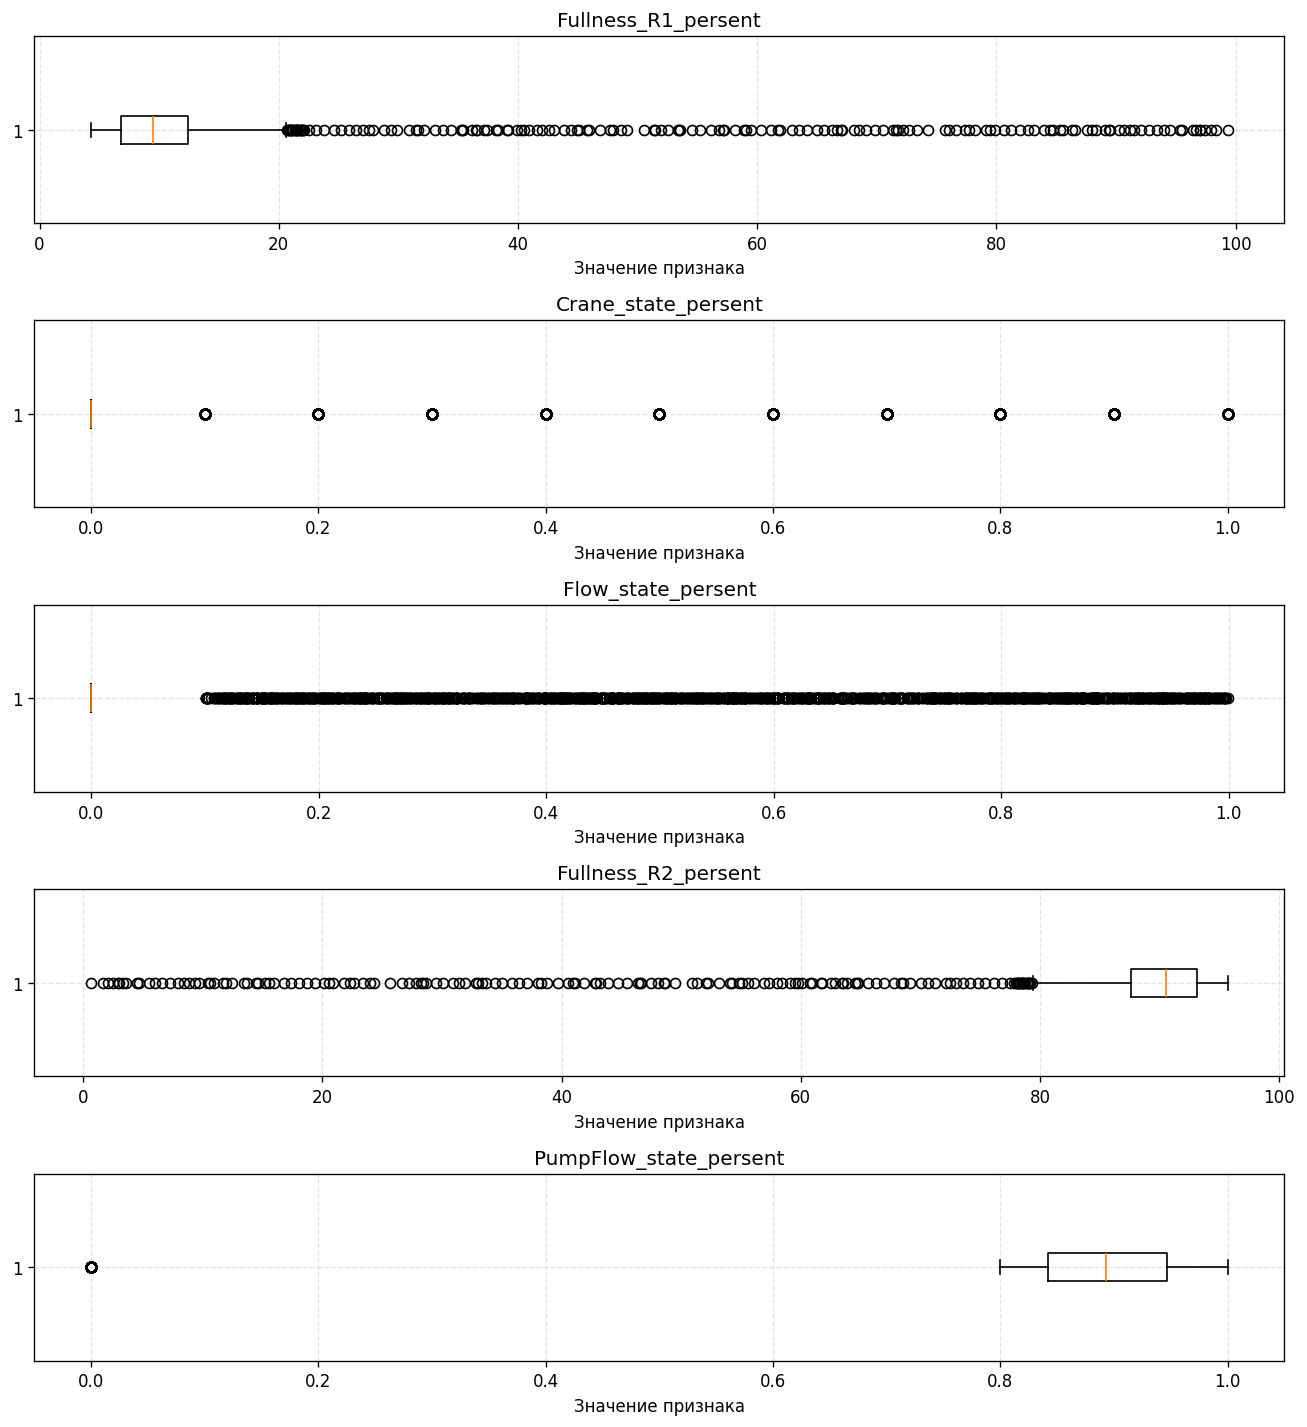

In [6]:
fig, axes = plt.subplots(len(continuous_cols), 1, figsize=(11, 12), sharex=False)
for ax, col in zip(axes, continuous_cols):
    ax.boxplot(df[col], vert=False, showfliers=True)
    ax.set_title(col)
    ax.set_xlabel("Значение признака")
plt.tight_layout()
plt.show()

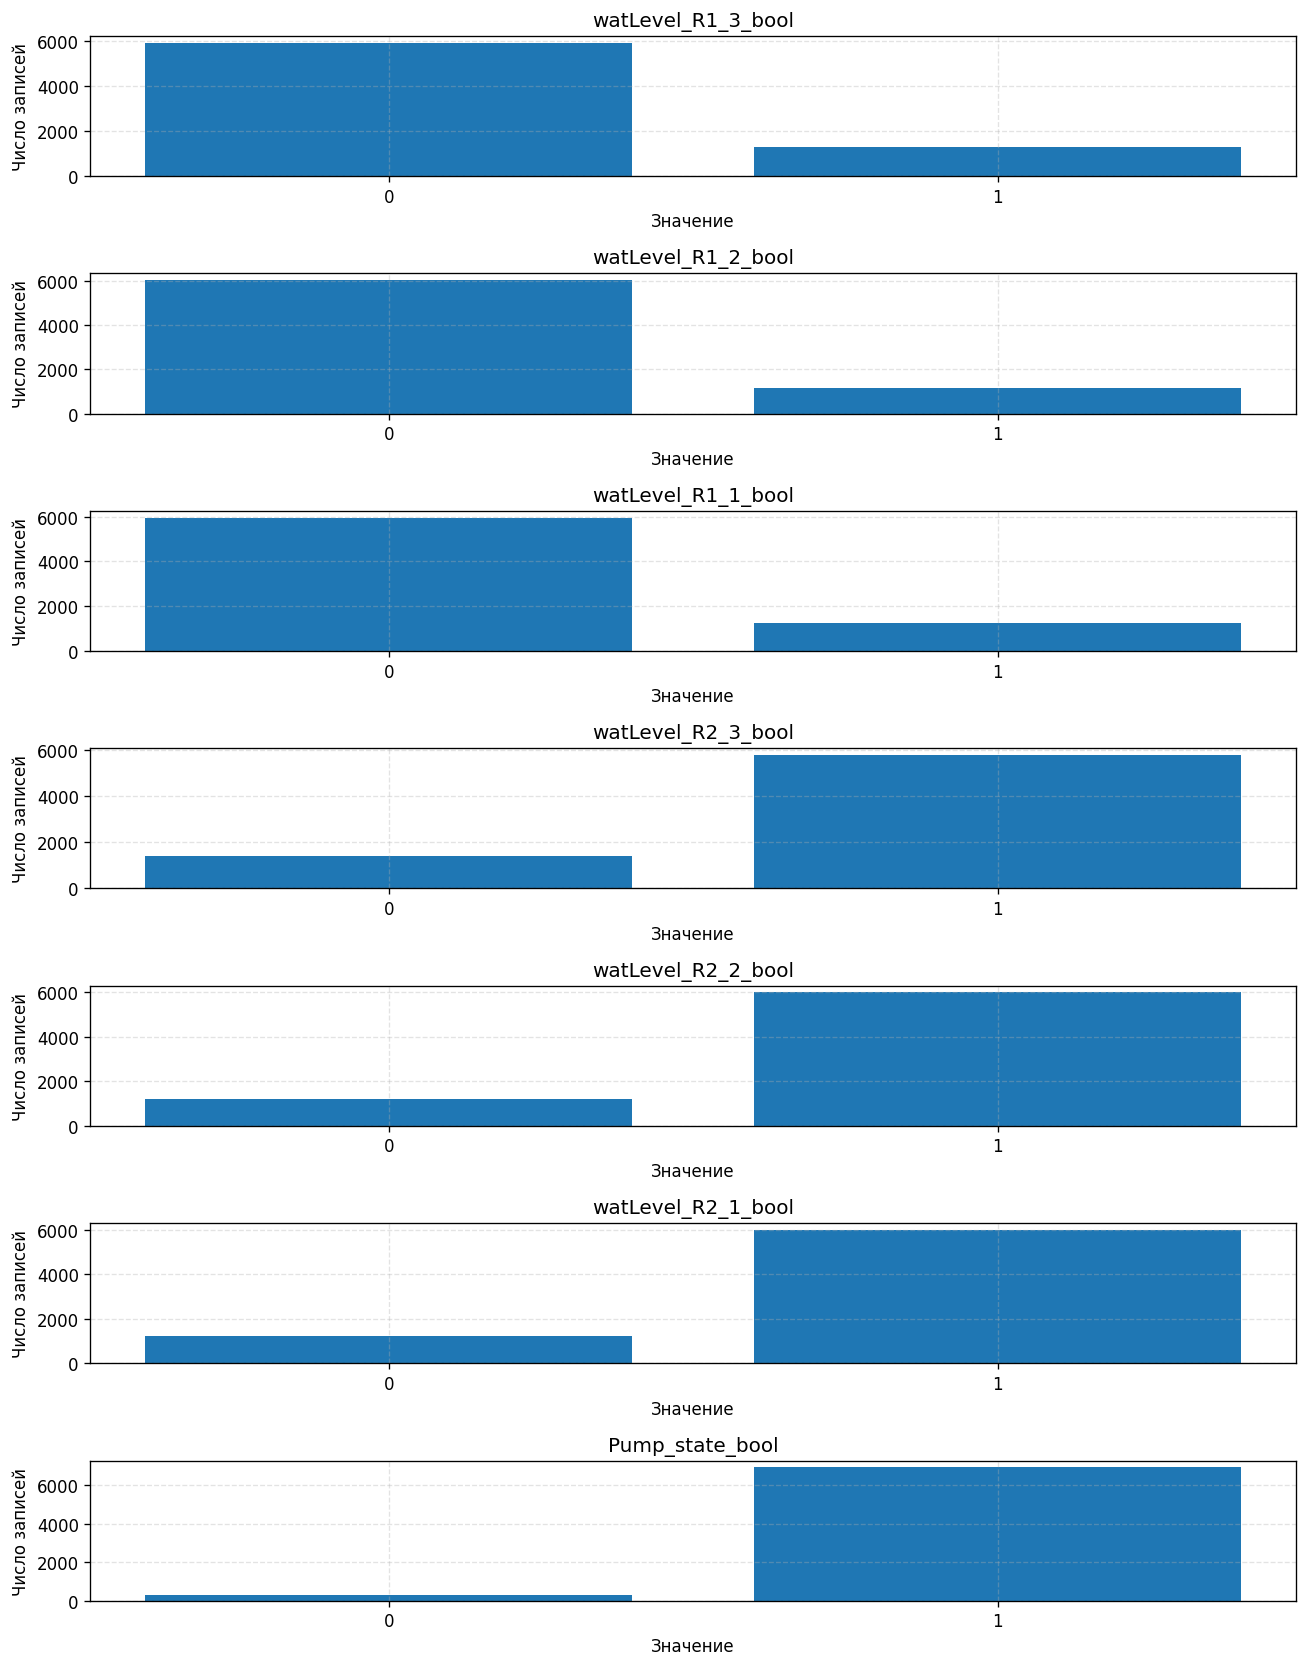

In [7]:
fig, axes = plt.subplots(len(binary_cols), 1, figsize=(11, 14), sharex=False)
for ax, col in zip(axes, binary_cols):
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(col)
    ax.set_xlabel("Значение")
    ax.set_ylabel("Число записей")
plt.tight_layout()
plt.show()

### Вывод по выбросам

По boxplot и гистограммам наиболее заметны экстремальные значения в признаках:

- `Fullness_R1_persent`
- `Fullness_R2_persent`
- `PumpFlow_state_persent`
- `Crane_state_persent`
- `Flow_state_persent`

Но для булевых и близких к ним признаков это в основном не «ошибочные выбросы», а переходы между состояниями системы.  
Наиболее явно выделяется начальный участок сигнала, где система выходит на рабочий режим.

## 4. Переходный период системы

Так как это киберфизические данные, полезно посмотреть динамику признаков во времени.  
Ниже показаны основные параметры по номеру записи. По графикам видно, что система стабилизируется примерно после первых **200 записей** (около **100 секунд**). Этот участок можно рассматривать как переходный период.

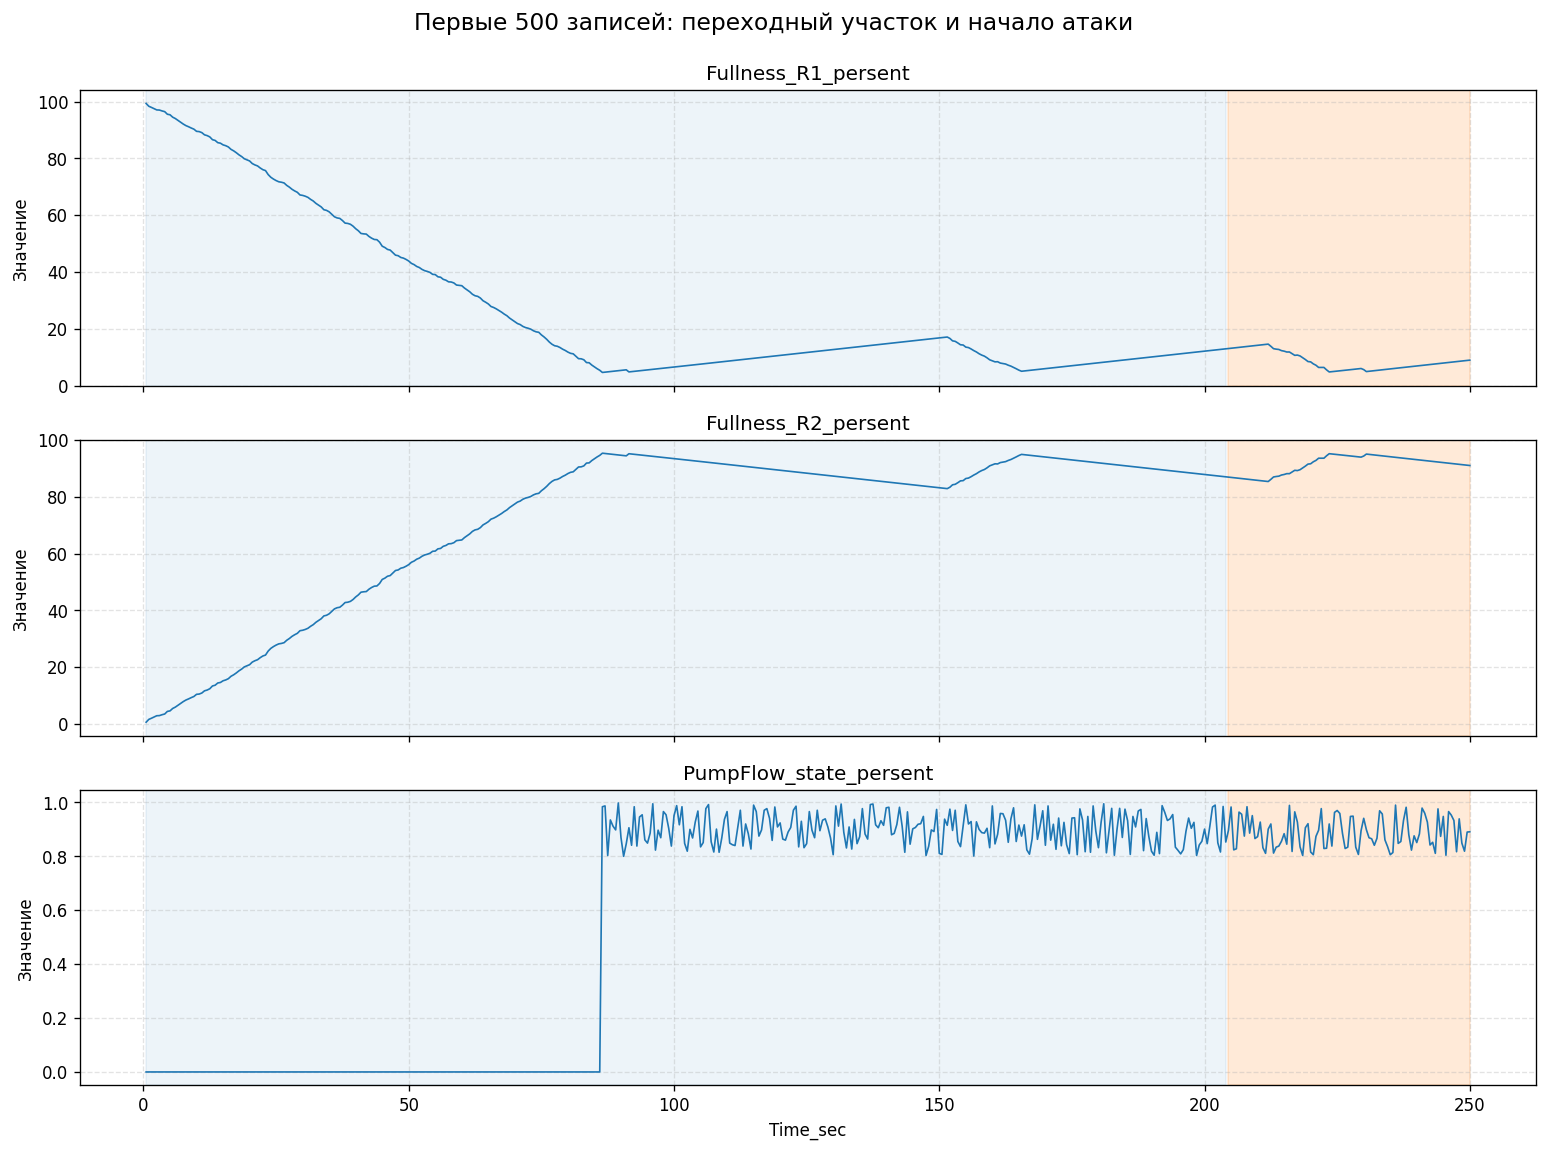

In [8]:

def plot_segments_background(ax, x, state):
    changes = np.where(np.diff(state.astype(int)) != 0)[0] + 1
    starts = np.r_[0, changes]
    ends = np.r_[changes, len(state)]
    for s, e in zip(starts, ends):
        cls = int(state[s])
        ax.axvspan(x[s], x[e-1], alpha=0.08 if cls == 0 else 0.16, color="tab:blue" if cls == 0 else "tab:orange")

fig, axes = plt.subplots(3, 1, figsize=(13, 3.2*3), sharex=True)
if 3 == 1:
    axes = [axes]
zoom = df.iloc[:500].copy()
for ax, col in zip(axes, ['Fullness_R1_persent', 'Fullness_R2_persent', 'PumpFlow_state_persent']):
    ax.plot(zoom["Time_sec"], zoom[col], linewidth=1.0)
    plot_segments_background(ax, zoom["Time_sec"].to_numpy(), zoom["classAttack"].to_numpy())
    ax.set_title(col)
    ax.set_ylabel("Значение")
axes[-1].set_xlabel("Time_sec")
fig.suptitle("Первые 500 записей: переходный участок и начало атаки", y=0.995, fontsize=14)
plt.tight_layout()
plt.show()


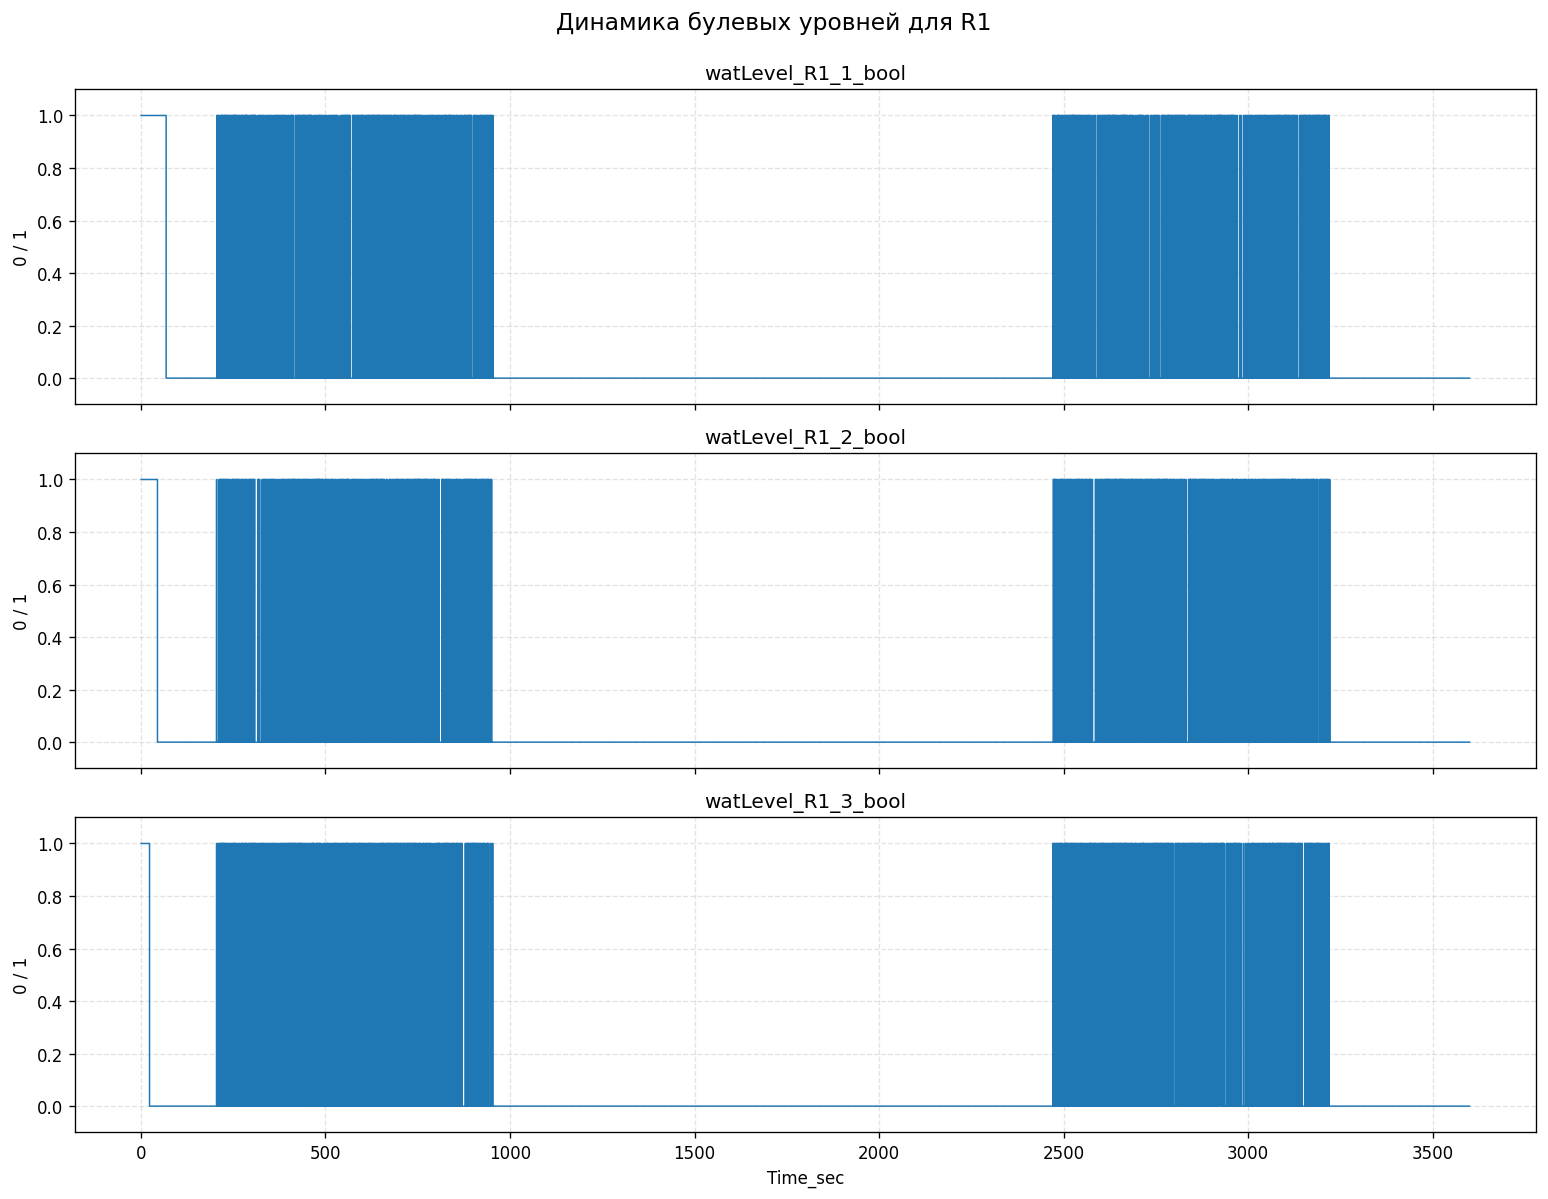

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
plot_cols = ["watLevel_R1_1_bool", "watLevel_R1_2_bool", "watLevel_R1_3_bool"]
for ax, col in zip(axes, plot_cols):
    ax.step(df["Time_sec"], df[col], where="mid", linewidth=0.9)
    ax.set_title(col)
    ax.set_ylim(-0.1, 1.1)
    ax.set_ylabel("0 / 1")
axes[-1].set_xlabel("Time_sec")
fig.suptitle("Динамика булевых уровней для R1", y=0.995, fontsize=14)
plt.tight_layout()
plt.show()

## 5. Двумерный анализ и корреляция

Для классификации особенно полезны признаки, которые хорошо различаются по классам и при этом не дублируют друг друга слишком сильно.  
Сначала посмотрим на корреляцию с целевым атрибутом `classAttack`.

,correlation_with_classAttack
classAttack,1.000000
isAttack,1.000000
watLevel_R1_3_bool,0.514385
watLevel_R2_1_bool,-0.496585
watLevel_R2_3_bool,-0.488481
watLevel_R2_2_bool,-0.463593
watLevel_R1_2_bool,0.452359
watLevel_R1_1_bool,0.439701
Pump_state_bool,0.170636
PumpFlow_state_persent,0.155121


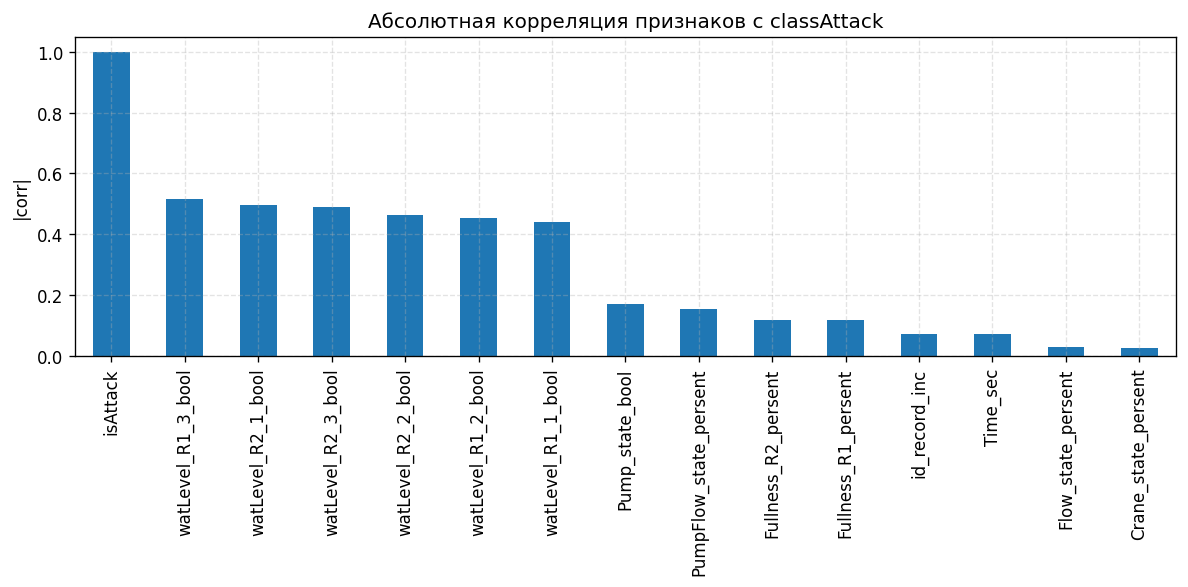

In [10]:
corr_target = df.corr(numeric_only=True)["classAttack"].sort_values(key=lambda s: s.abs(), ascending=False)
display(corr_target.to_frame("correlation_with_classAttack"))

plt.figure(figsize=(10, 5))
corr_target.drop(labels=["classAttack"]).abs().sort_values(ascending=False).plot(kind="bar")
plt.title("Абсолютная корреляция признаков с classAttack")
plt.ylabel("|corr|")
plt.tight_layout()
plt.show()

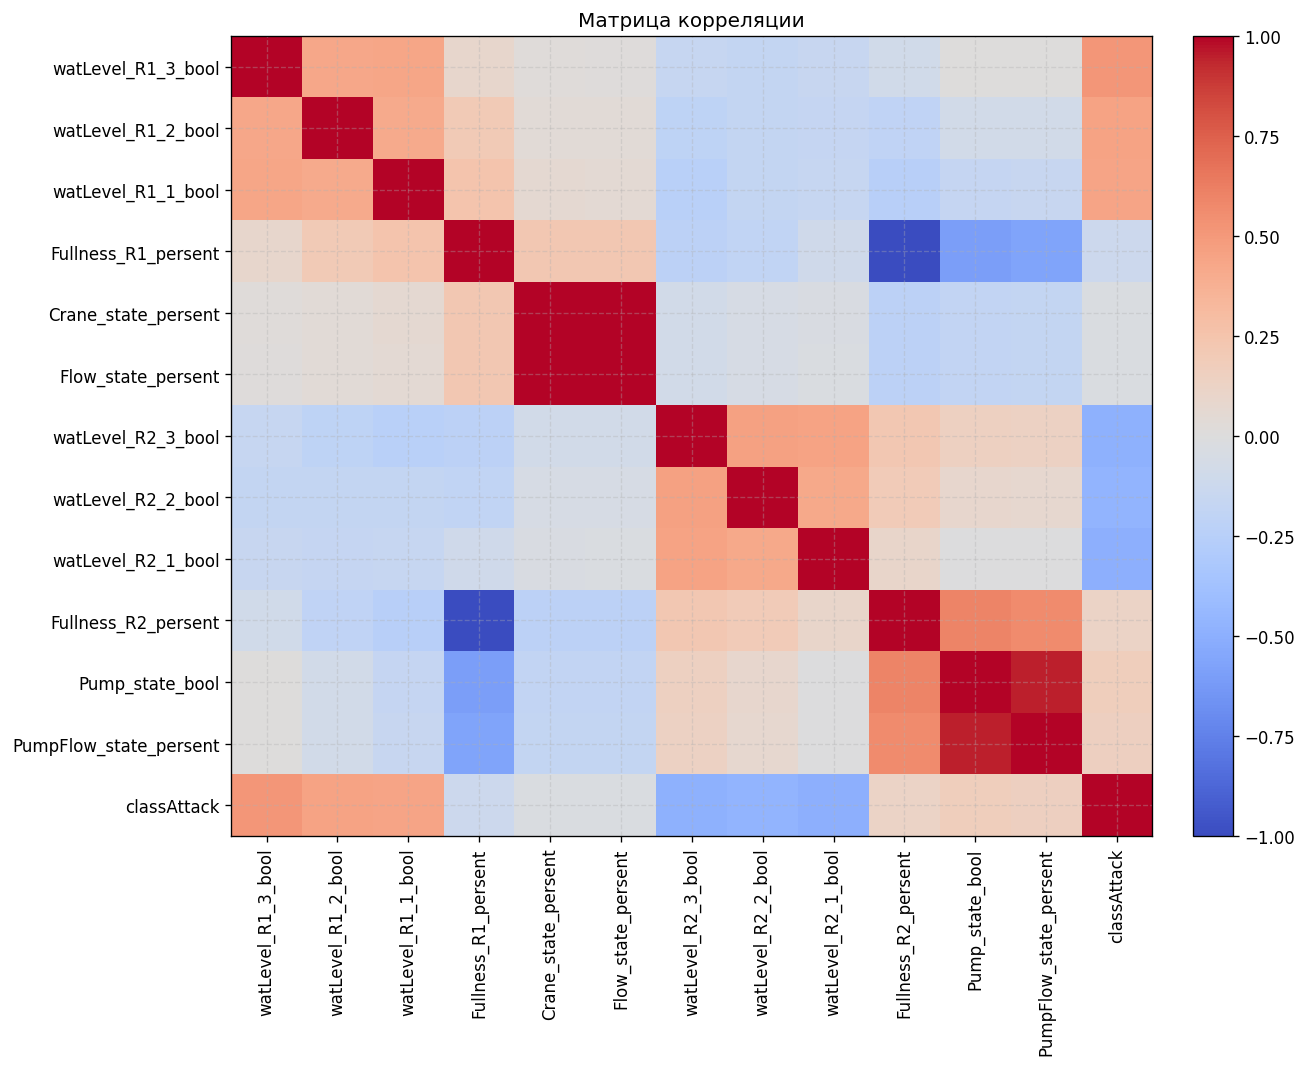

In [11]:
corr = df[feature_cols + ["classAttack"]].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, interpolation="nearest", aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Матрица корреляции")
plt.tight_layout()
plt.show()

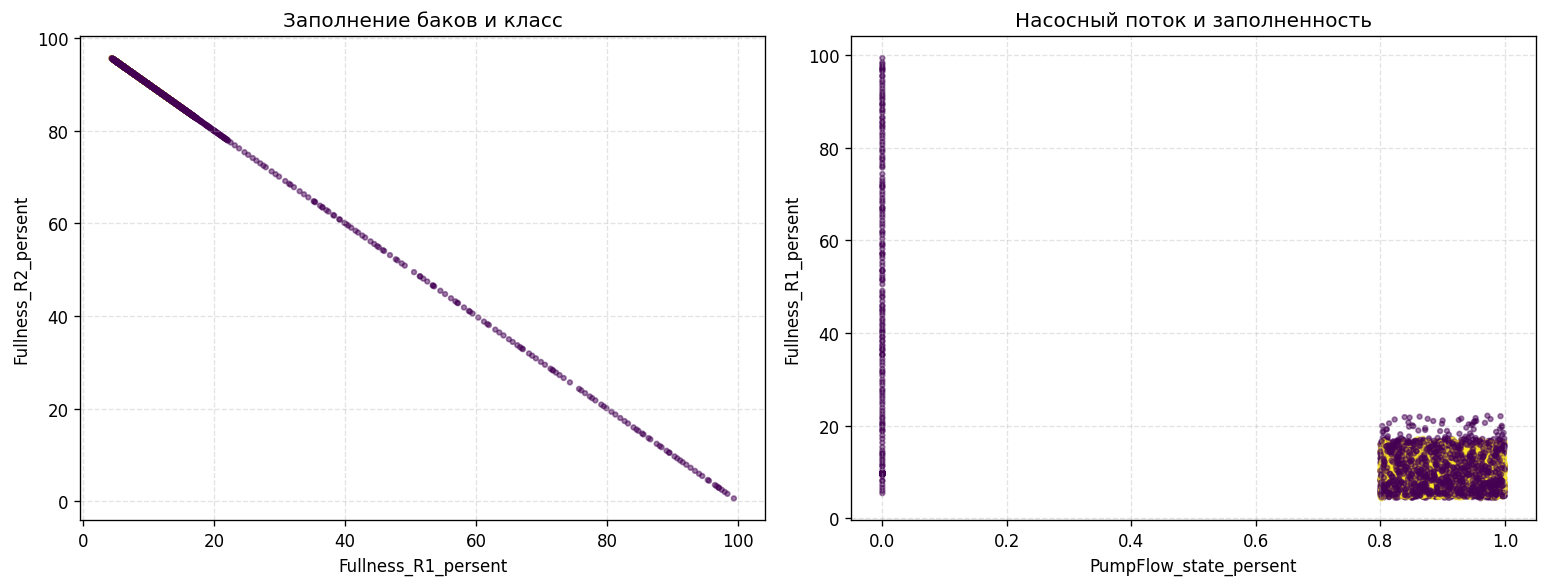

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["Fullness_R1_persent"], df["Fullness_R2_persent"], c=df["classAttack"], s=8, alpha=0.5)
axes[0].set_xlabel("Fullness_R1_persent")
axes[0].set_ylabel("Fullness_R2_persent")
axes[0].set_title("Заполнение баков и класс")

axes[1].scatter(df["PumpFlow_state_persent"], df["Fullness_R1_persent"], c=df["classAttack"], s=8, alpha=0.5)
axes[1].set_xlabel("PumpFlow_state_persent")
axes[1].set_ylabel("Fullness_R1_persent")
axes[1].set_title("Насосный поток и заполненность")

plt.tight_layout()
plt.show()

### Вывод по наиболее интересным признакам

Наиболее полезными для задачи классификации выглядят:

1. `watLevel_R1_1_bool`, `watLevel_R1_2_bool`, `watLevel_R1_3_bool`  
   — хорошо отделяют норму и атаку, корреляция с `classAttack` заметная и положительная.

2. `watLevel_R2_1_bool`, `watLevel_R2_2_bool`, `watLevel_R2_3_bool`  
   — также информативны, но с отрицательной корреляцией: при атаке их значения меняются в противоположную сторону.

3. `Fullness_R1_persent` и `Fullness_R2_persent`  
   — показывают устойчивое смещение уровней между нормой и атакой.

4. `Pump_state_bool` и `PumpFlow_state_persent`  
   — полезны, потому что отражают состояние насоса и связаны с переключением режимов.

Признаки `id_record_inc` и `Time_sec` лучше не использовать как входные признаки модели: они описывают только порядок наблюдений.  
`isAttack` исключается, потому что это дубликат целевого атрибута `classAttack`.

## 6. Итоговые ответы на вопросы

**1) Есть ли выбросы?**  
Да. Наиболее заметны выбросы/экстремальные значения в `Fullness_R1_persent`, `Fullness_R2_persent`, `PumpFlow_state_persent`, а также в состояниях `Crane_state_persent` и `Flow_state_persent`.  
При этом для бинарных признаков часть «выбросов» — это обычная смена состояния, а не ошибка измерения.

**2) Есть ли переходный период?**  
Да. По линейным графикам система выходит на режим примерно после первых **200 записей** (около **100 секунд**). Этот участок можно выделить как переходный.

**3) Какие признаки наиболее интересны для классификации?**  
Самыми интересными являются признаки уровней воды слева и справа (`watLevel_R1_*_bool`, `watLevel_R2_*_bool`), а также `Fullness_R1_persent`, `Fullness_R2_persent`, `Pump_state_bool`, `PumpFlow_state_persent`.  
Они лучше всего разделяют классы на графиках и имеют наибольшую связь с целевым атрибутом `classAttack`.